# 01 — Data Processing & Trading-Day Alignment

**Project:** News Sentiments Analysis (Vietnam)

This notebook is a thin **execution and inspection layer** over
`src/preprocessing/pipeline.py`.  Core data logic lives in the module;
the notebook calls it, then presents diagnostics and exploratory plots.

| Input | Path |
|-------|------|
| Raw CafeF news | `data/raw/news_VN_cafef.csv` |
| VN-Index prices | `data/raw/prices_VN.csv` |

| Output | Path |
|--------|------|
| Clean article dataset | `data/main/processed/articles_clean.parquet` |
| Daily news + prices | `data/main/processed/daily_news_prices.parquet` |
| Diagnostics summary | `data/main/processed/preprocessing_diagnostics.json` |


---
## 0 — Setup & Imports

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

# Make sure the project root is on sys.path when running interactively.
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.preprocessing.pipeline import (
    build_preprocessed_outputs,
    export_preprocessed_outputs,
)
from src.data.backup_raw import backup_raw_csv

DATA_DIR    = ROOT / 'data'
RAW_NEWS    = DATA_DIR / 'raw' / 'news_VN_cafef.csv'
PRICES      = DATA_DIR / 'raw' / 'prices_VN.csv'
OUT_DIR     = DATA_DIR / 'main' / 'processed'

print('Root     :', ROOT)
print('Raw news :', RAW_NEWS)
print('Prices   :', PRICES)
print('Out dir  :', OUT_DIR)


Root     : /Users/bunnypro/Projects/news-sentiments-analysis
Raw news : /Users/bunnypro/Projects/news-sentiments-analysis/data/raw/news_VN_cafef.csv
Prices   : /Users/bunnypro/Projects/news-sentiments-analysis/data/raw/prices_VN.csv
Out dir  : /Users/bunnypro/Projects/news-sentiments-analysis/data/main/processed


---
## 1 — Raw Input Schema & Row Count Check

In [2]:
import csv
csv.field_size_limit(2_147_483_647)

# Read header and count rows without loading the full 966 MB into memory.
with open(RAW_NEWS, newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    raw_columns = reader.fieldnames
    raw_row_count = sum(1 for _ in reader)

print(f'Columns ({len(raw_columns)}):', raw_columns)
print(f'Row count (excl. header): {raw_row_count:,}')

# Schema check: required columns.
REQUIRED_COLS = {'url', 'source', 'category', 'title', 'date', 'body'}
missing_cols = REQUIRED_COLS - set(raw_columns)
assert not missing_cols, f'Raw CSV missing required columns: {missing_cols}'
print('\n✓ All required columns present.')

has_published_at = 'published_at' in raw_columns
print(f"published_at column present: {has_published_at}")
if not has_published_at:
    print("  → Date-only alignment will be used (no intraday cutoff available).")
    print("  → After-close share will be 0%. Run a fresh scrape to populate published_at.")


Columns (7): ['url', 'source', 'category', 'title', 'date', 'published_at', 'body']
Row count (excl. header): 86,234

✓ All required columns present.
published_at column present: True


---
## 2 — Backup Raw Data

In [3]:
# Back up the raw CafeF CSV before any pipeline overwrites.
# Skips silently if today's backup already exists.
backup_path = backup_raw_csv(RAW_NEWS)
print('Backup path:', backup_path)


Backup path: /Users/bunnypro/Projects/news-sentiments-analysis/data/news_VN_cafef_backup_20260524.csv


---
## 3 — Run Preprocessing Pipeline

In [4]:
articles_df, daily_df, diagnostics = build_preprocessed_outputs(
    RAW_NEWS,
    PRICES,
    min_body_len=100,
)

print(f'articles_df : {len(articles_df):,} rows × {len(articles_df.columns)} cols')
print(f'daily_df    : {len(daily_df):,} rows × {len(daily_df.columns)} cols')


8 articles could not be mapped to a trading day (unmapped) — dropping.


articles_df : 86,179 rows × 14 cols
daily_df    : 2,498 rows × 13 cols


In [5]:
paths = export_preprocessed_outputs(
    articles_df,
    daily_df,
    diagnostics,
    out_dir=OUT_DIR,
)
for name, path in paths.items():
    print(f'{name:20s} → {path}')


articles_clean       → /Users/bunnypro/Projects/news-sentiments-analysis/data/main/processed/articles_clean.parquet
daily_news_prices    → /Users/bunnypro/Projects/news-sentiments-analysis/data/main/processed/daily_news_prices.parquet
diagnostics          → /Users/bunnypro/Projects/news-sentiments-analysis/data/main/processed/preprocessing_diagnostics.json


---
## 4 — Diagnostics Summary

In [6]:
import json
print(json.dumps(diagnostics, indent=2, ensure_ascii=False))


{
  "generated_at": "2026-05-24T12:57:50",
  "raw_news_path": "/Users/bunnypro/Projects/news-sentiments-analysis/data/raw/news_VN_cafef.csv",
  "price_path": "/Users/bunnypro/Projects/news-sentiments-analysis/data/raw/prices_VN.csv",
  "raw_cafef_row_count": 86234,
  "after_short_filter_row_count": 86187,
  "short_articles_removed": 47,
  "min_body_len_threshold": 100,
  "unmapped_articles_dropped": 8,
  "cleaned_article_row_count": 86179,
  "published_at_non_null_share": 1.0,
  "timestamp_based_alignment_share": 1.0,
  "date_only_fallback_share": 0.0,
  "after_close_forward_shifts": 25041,
  "non_trading_day_forward_shifts": 16563,
  "processed_daily_row_count": 2498,
  "price_row_count": 2498,
  "daily_vs_price_row_diff": 0,
  "daily_vs_price_explanation": "daily_news_prices row count equals price row count (all trading days preserved)."
}


In [7]:
# published_at coverage
ts_share = diagnostics['timestamp_based_alignment_share']
do_share = diagnostics['date_only_fallback_share']
print(f"Timestamp-based alignment  : {ts_share:.1%}")
print(f"Date-only fallback         : {do_share:.1%}")
print(f"After-close forward shifts : {diagnostics['after_close_forward_shifts']:,}")
print(f"Non-trading forward shifts : {diagnostics['non_trading_day_forward_shifts']:,}")


Timestamp-based alignment  : 100.0%
Date-only fallback         : 0.0%
After-close forward shifts : 25,041
Non-trading forward shifts : 16,563


---
## 5 — Daily Row-Count Reconciliation

In [8]:
# Load price file to get its exact row count.
prices_raw = pd.read_csv(PRICES, parse_dates=['Date'])
price_rows = len(prices_raw)
daily_rows = len(daily_df)

print(f'data/raw/prices_VN.csv  : {price_rows:,} trading days')
print(f'daily_news_prices   : {daily_rows:,} rows')
print(f'Difference          : {price_rows - daily_rows:+,}')
print()
print('Explanation:', diagnostics['daily_vs_price_explanation'])

# Zero-news days (n_articles == 0) should make sense.
zero_news = (daily_df['n_articles'] == 0).sum()
print(f'\nTrading days with zero news articles: {zero_news:,}')


data/raw/prices_VN.csv  : 2,498 trading days
daily_news_prices   : 2,498 rows
Difference          : +0

Explanation: daily_news_prices row count equals price row count (all trading days preserved).

Trading days with zero news articles: 4


---
## 6 — Alignment Diagnostics

In [9]:
reason_counts = articles_df['alignment_reason'].value_counts()
print('Alignment reason breakdown:')
print(reason_counts.to_string())
print()
print(f"has_timestamp=1  : {articles_df['has_timestamp'].sum():,}")
print(f"is_after_close=1 : {articles_df['is_after_close'].sum():,}")
print(f"max calendar gap : {articles_df['calendar_gap_days'].max():.0f} days")


Alignment reason breakdown:
alignment_reason
same_session           44575
after_close_forward    25041
non_trading_forward    16563

has_timestamp=1  : 86,179
is_after_close=1 : 25,041
max calendar gap : 11 days


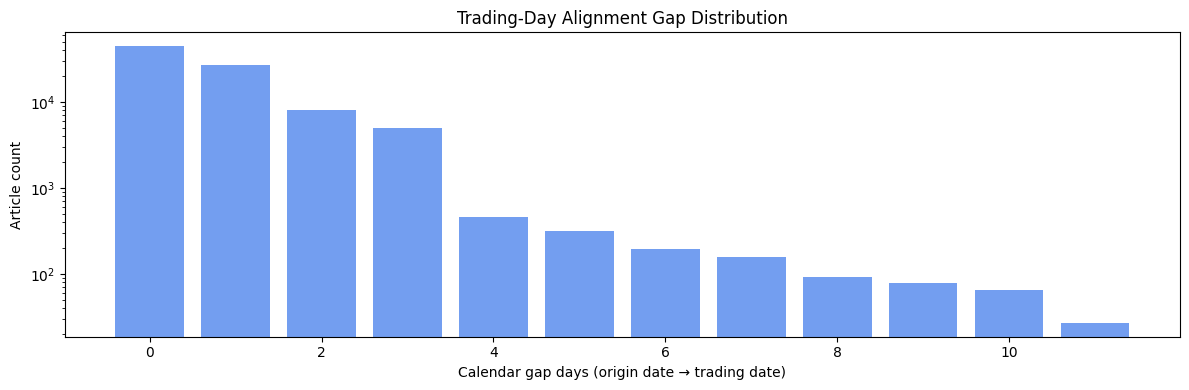

In [10]:
# Calendar gap distribution
fig, ax = plt.subplots(figsize=(12, 4))
gap_counts = articles_df['calendar_gap_days'].value_counts().sort_index()
ax.bar(gap_counts.index.astype(int), gap_counts.values, color='#5b8dee', alpha=0.85)
ax.set_xlabel('Calendar gap days (origin date → trading date)')
ax.set_ylabel('Article count')
ax.set_title('Trading-Day Alignment Gap Distribution')
ax.set_yscale('log')
plt.tight_layout()
plt.show()


---
## 7 — Exploratory Analysis

### 7.1 Category Distribution

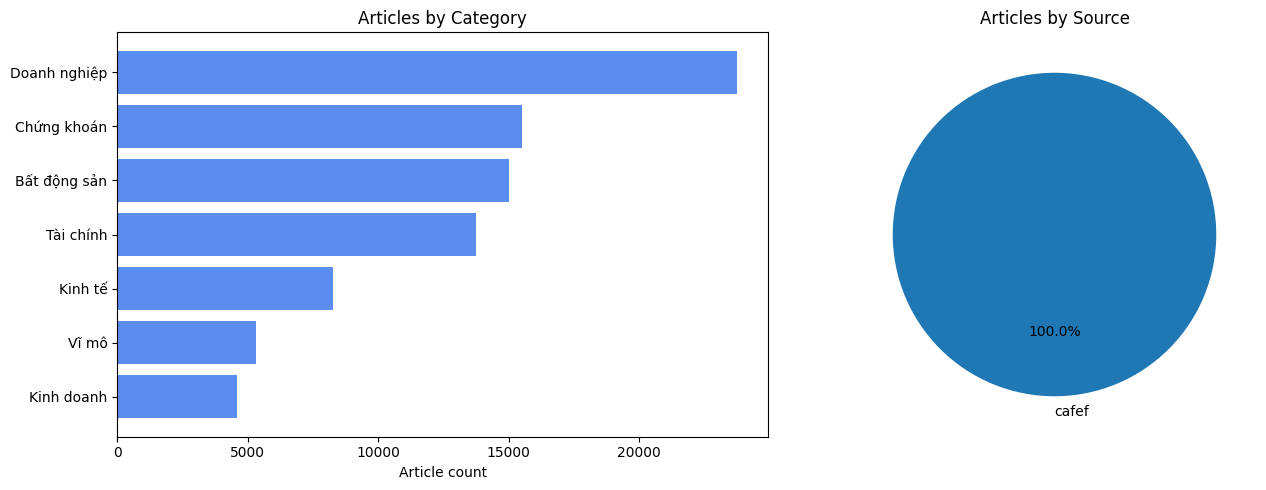

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category bar chart
cat_counts = articles_df['category'].value_counts()
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color='#5b8dee')
axes[0].set_xlabel('Article count')
axes[0].set_title('Articles by Category')

# Source pie
src_counts = articles_df['source'].value_counts()
axes[1].pie(src_counts.values, labels=src_counts.index,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Articles by Source')

plt.tight_layout()
plt.show()


### 7.2 Daily Article Volume Over Time

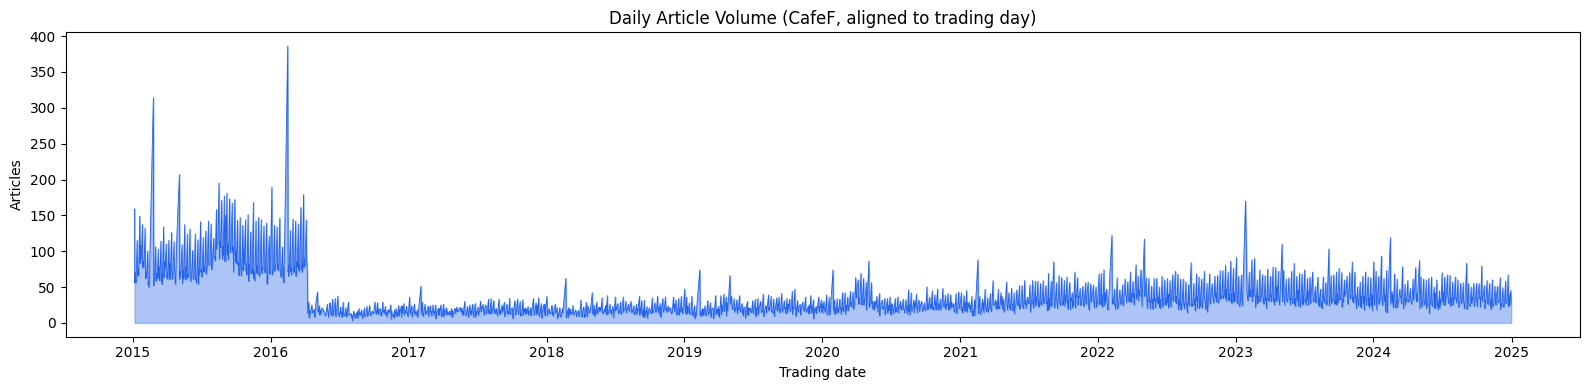

In [12]:
articles_df['trading_date_dt'] = pd.to_datetime(articles_df['trading_date'])
daily_counts = (
    articles_df.groupby('trading_date_dt').size().reset_index(name='n_articles')
)

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(daily_counts['trading_date_dt'], daily_counts['n_articles'],
                alpha=0.5, color='#5b8dee')
ax.plot(daily_counts['trading_date_dt'], daily_counts['n_articles'],
        linewidth=0.6, color='#2563eb')
ax.set_xlabel('Trading date')
ax.set_ylabel('Articles')
ax.set_title('Daily Article Volume (CafeF, aligned to trading day)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()


### 7.3 Monthly Volume Heatmap

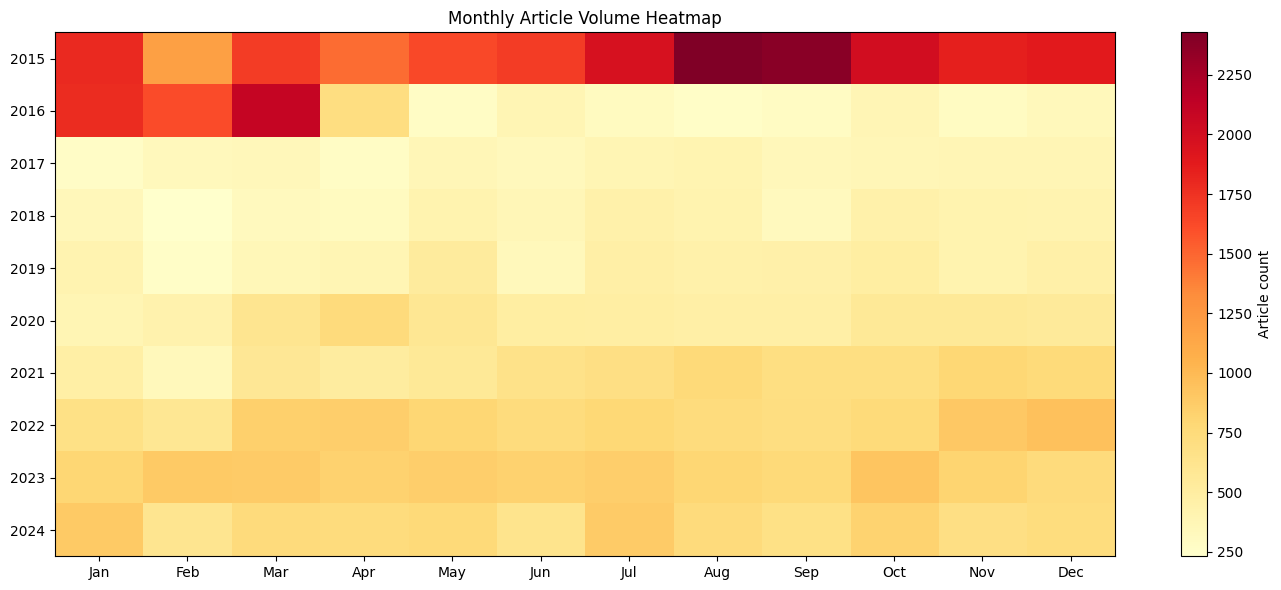

In [13]:
articles_df['year']  = articles_df['trading_date_dt'].dt.year
articles_df['month'] = articles_df['trading_date_dt'].dt.month
monthly_pivot = (
    articles_df.groupby(['year', 'month']).size().unstack('month').fillna(0)
)

import matplotlib.ticker as ticker
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(monthly_pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(monthly_pivot.index)))
ax.set_yticklabels(monthly_pivot.index.astype(int))
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.colorbar(im, ax=ax, label='Article count')
ax.set_title('Monthly Article Volume Heatmap')
plt.tight_layout()
plt.show()


### 7.4 VN-Index Price + Daily News Overlay

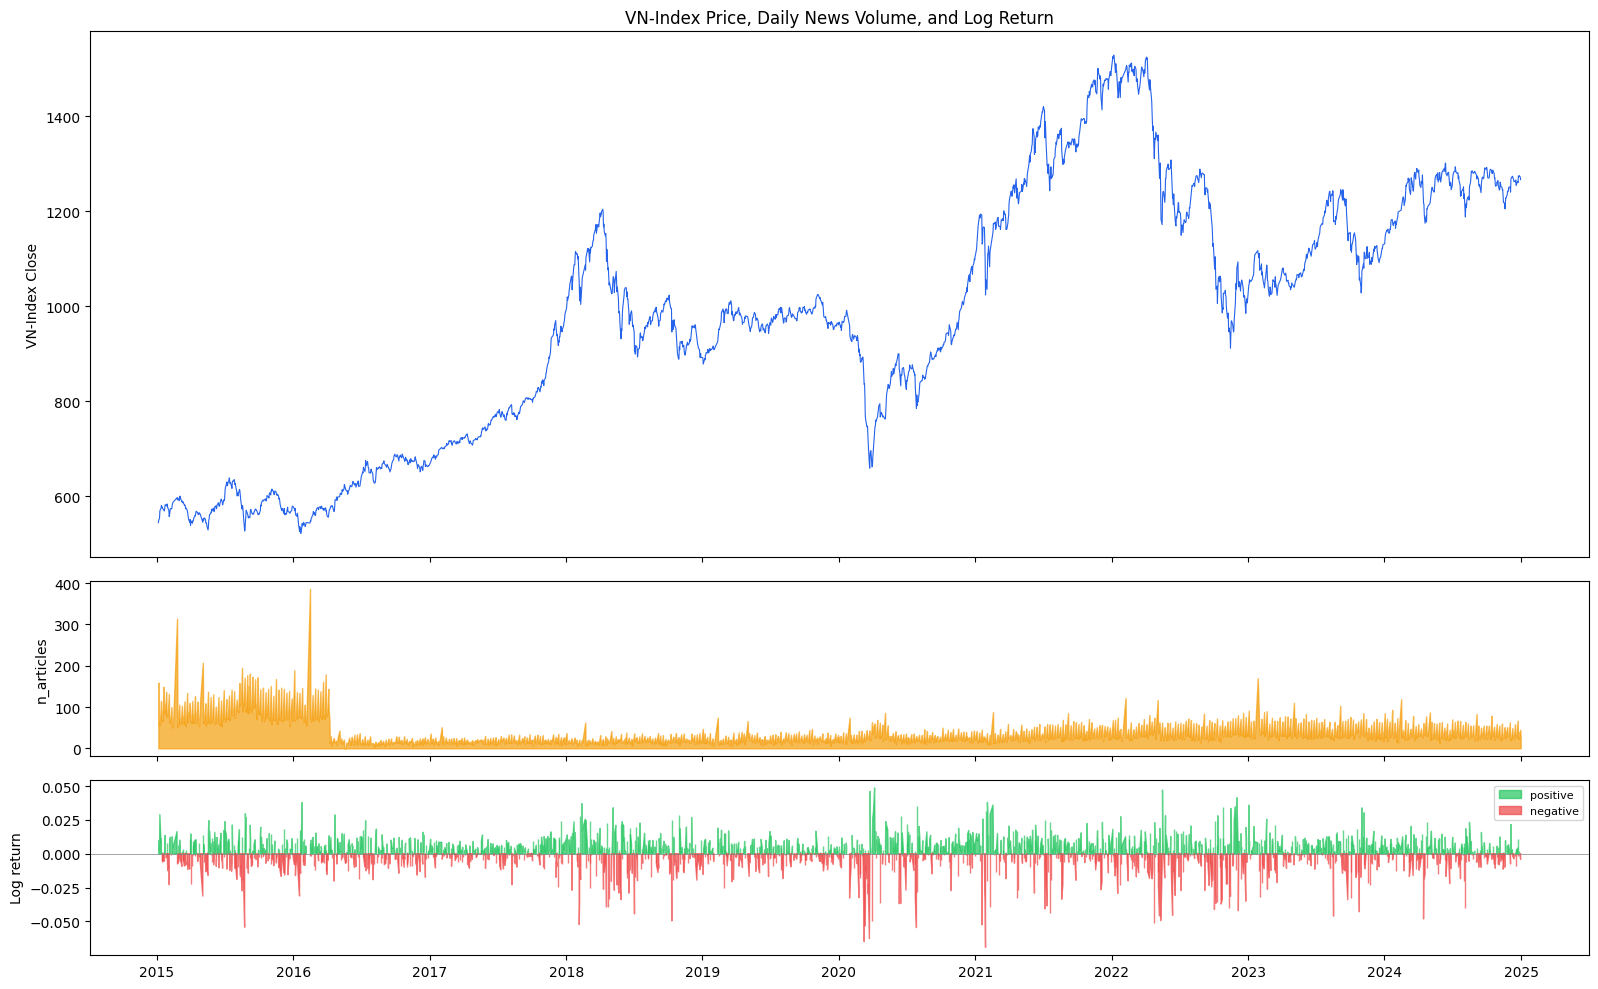

In [14]:
daily_merged = daily_df.copy()
daily_merged['date'] = pd.to_datetime(daily_merged['date'])

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1, 1]})

# Price
axes[0].plot(daily_merged['date'], daily_merged['close'], color='#2563eb', linewidth=0.8)
axes[0].set_ylabel('VN-Index Close')
axes[0].set_title('VN-Index Price, Daily News Volume, and Log Return')

# Article count
axes[1].fill_between(daily_merged['date'], daily_merged['n_articles'],
                     alpha=0.7, color='#f59e0b')
axes[1].set_ylabel('n_articles')

# Log return
axes[2].fill_between(daily_merged['date'], daily_merged['log_return'],
                     where=daily_merged['log_return'] >= 0,
                     color='#22c55e', alpha=0.7, label='positive')
axes[2].fill_between(daily_merged['date'], daily_merged['log_return'],
                     where=daily_merged['log_return'] < 0,
                     color='#ef4444', alpha=0.7, label='negative')
axes[2].axhline(0, color='grey', linewidth=0.5)
axes[2].set_ylabel('Log return')
axes[2].legend(loc='upper right', fontsize=8)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


### 7.5 Body Length Distribution

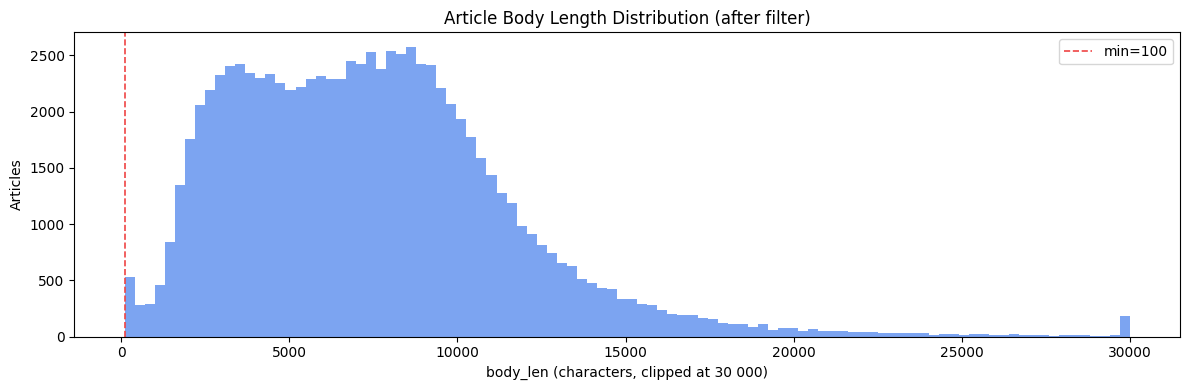

median body_len : 7088 chars
mean body_len   : 7467 chars


In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(articles_df['body_len'].clip(upper=30_000), bins=100,
        color='#5b8dee', alpha=0.8, edgecolor='none')
ax.axvline(100, color='#ef4444', linestyle='--', linewidth=1.2, label='min=100')
ax.set_xlabel('body_len (characters, clipped at 30 000)')
ax.set_ylabel('Articles')
ax.set_title('Article Body Length Distribution (after filter)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"median body_len : {articles_df['body_len'].median():.0f} chars")
print(f"mean body_len   : {articles_df['body_len'].mean():.0f} chars")


### 7.6 Correlation: News Intensity vs. Log Return

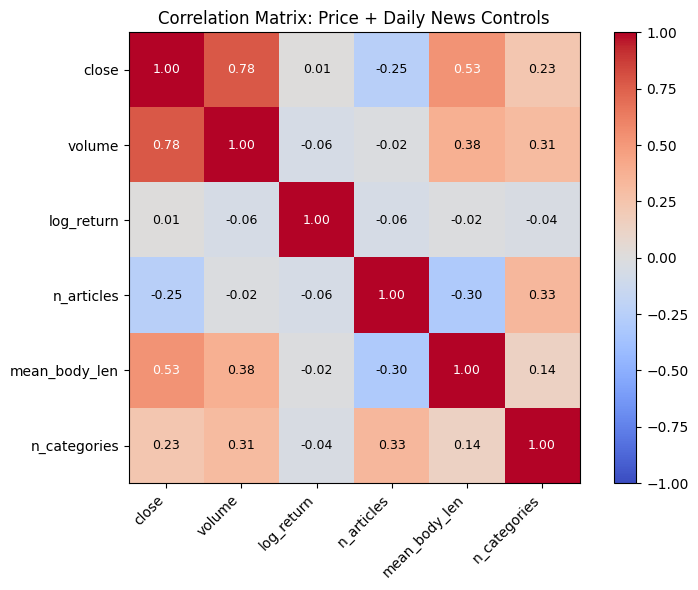

In [16]:
corr_cols = ['close', 'volume', 'log_return', 'n_articles',
             'mean_body_len', 'n_categories']
corr_cols_present = [c for c in corr_cols if c in daily_df.columns]
corr = daily_df[corr_cols_present].dropna().corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_cols_present)))
ax.set_yticks(range(len(corr_cols_present)))
ax.set_xticklabels(corr_cols_present, rotation=45, ha='right')
ax.set_yticklabels(corr_cols_present)
for i in range(len(corr_cols_present)):
    for j in range(len(corr_cols_present)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
ax.set_title('Correlation Matrix: Price + Daily News Controls')
plt.tight_layout()
plt.show()


---
## 8 — Output Schema Verification

In [17]:
# Reload from disk to confirm round-trip integrity.
articles_reload = pd.read_parquet(OUT_DIR / 'articles_clean.parquet')
daily_reload    = pd.read_parquet(OUT_DIR / 'daily_news_prices.parquet')

print('articles_clean.parquet columns:')
print('  ', list(articles_reload.columns))
print(f'  {len(articles_reload):,} rows')
print()
print('daily_news_prices.parquet columns:')
print('  ', list(daily_reload.columns))
print(f'  {len(daily_reload):,} rows')

# Contract assertions
ARTICLES_CONTRACT = [
    'url', 'source', 'category', 'title', 'date', 'published_at',
    'origin_date', 'trading_date', 'has_timestamp', 'is_after_close',
    'alignment_reason', 'calendar_gap_days', 'body_clean', 'body_len',
]
DAILY_CONTRACT = [
    'date', 'close', 'n_articles', 'n_categories', 'mean_body_len',
    'after_close_share', 'non_trading_share', 'max_calendar_gap_days', 'log_return',
]
missing_a = [c for c in ARTICLES_CONTRACT if c not in articles_reload.columns]
missing_d = [c for c in DAILY_CONTRACT if c not in daily_reload.columns]
assert not missing_a, f'articles_clean.parquet missing contract cols: {missing_a}'
assert not missing_d, f'daily_news_prices.parquet missing contract cols: {missing_d}'
print()
print('✓ Both output schemas satisfy their contracts.')


articles_clean.parquet columns:
   ['url', 'source', 'category', 'title', 'date', 'published_at', 'origin_date', 'trading_date', 'has_timestamp', 'is_after_close', 'alignment_reason', 'calendar_gap_days', 'body_clean', 'body_len']
  86,179 rows

daily_news_prices.parquet columns:
   ['date', 'close', 'open', 'high', 'low', 'volume', 'log_return', 'n_articles', 'n_categories', 'mean_body_len', 'after_close_share', 'non_trading_share', 'max_calendar_gap_days']
  2,498 rows

✓ Both output schemas satisfy their contracts.


---
## Summary

All preprocessing steps completed successfully.

| Dataset | Rows | Description |
|---------|------|-------------|
| `articles_clean.parquet` | *see above* | Article-level with alignment diagnostics |
| `daily_news_prices.parquet` | *see above* | Daily trading-day merged frame |
| `preprocessing_diagnostics.json` | — | Machine-readable provenance summary |

Next step: run sentiment inference on `articles_clean.parquet`, then proceed to
`python -m src.modeling.run_experiment`.
